# Análise Exploratória dos dados utilizados no projeto

In [79]:
import pandas as pd
import matplotlib.pyplot as plt

df_fato = pd.read_parquet("project/data/fato_estabelecimentos.parquet")
df_data = pd.read_parquet("project/data/dim_data.parquet")


data = df_fato.merge(    
    df_data[['ID_DATA', 'DATA']],
    left_on='DATA_INICIO',
    right_on='ID_DATA',
    how='left'
)

data = data.drop(columns=['CNAE_FISCAL_SECUNDARIO'])

data.info()

<class 'pandas.DataFrame'>
RangeIndex: 1484339 entries, 0 to 1484338
Data columns (total 13 columns):
 #   Column                 Non-Null Count    Dtype  
---  ------                 --------------    -----  
 0   CNPJ                   1484339 non-null  str    
 1   LOCALIDADE             1484339 non-null  uint32 
 2   ATIVIDADE              1484339 non-null  uint32 
 3   PERFIL                 1100664 non-null  float64
 4   SITUACAO               1484339 non-null  uint32 
 5   DATA_INICIO            1484339 non-null  uint32 
 6   DATA_OPCAO_SIMPLES     1100664 non-null  float64
 7   DATA_EXCLUSAO_SIMPLES  538528 non-null   float64
 8   DATA_OPCAO_MEI         835401 non-null   float64
 9   DATA_EXCLUSAO_MEI      430484 non-null   float64
 10  MATRIZ_FILIAL          1484339 non-null  int32  
 11  ID_DATA                1484339 non-null  uint32 
 12  DATA                   1484339 non-null  object 
dtypes: float64(5), int32(1), object(1), str(1), uint32(5)
memory usage: 133.1+ MB


In [80]:
data.value_counts()

CNPJ            LOCALIDADE  ATIVIDADE  PERFIL  SITUACAO  DATA_INICIO  DATA_OPCAO_SIMPLES  DATA_EXCLUSAO_SIMPLES  DATA_OPCAO_MEI  DATA_EXCLUSAO_MEI  MATRIZ_FILIAL  ID_DATA  DATA      
03413244000194  201775      1149       3.0     4         8690         16285.0             14198.0                7756.0          14198.0            1              8690     1999-08-11    1
65210424000126  211628      1091       3.0     4         4777         4777.0              16601.0                4777.0          16601.0            1              4777     2026-02-20    1
65220218000105  1828        420        3.0     4         4777         4777.0              11925.0                4777.0          11925.0            1              4777     2026-02-20    1
64756785000100  110877      356        3.0     4         12563        12563.0             16936.0                12563.0         16936.0            1              12563    2026-01-28    1
65075746000100  177400      168        3.0     4         14978   

## Visualização da evolução histórica de abertura de CNPJs

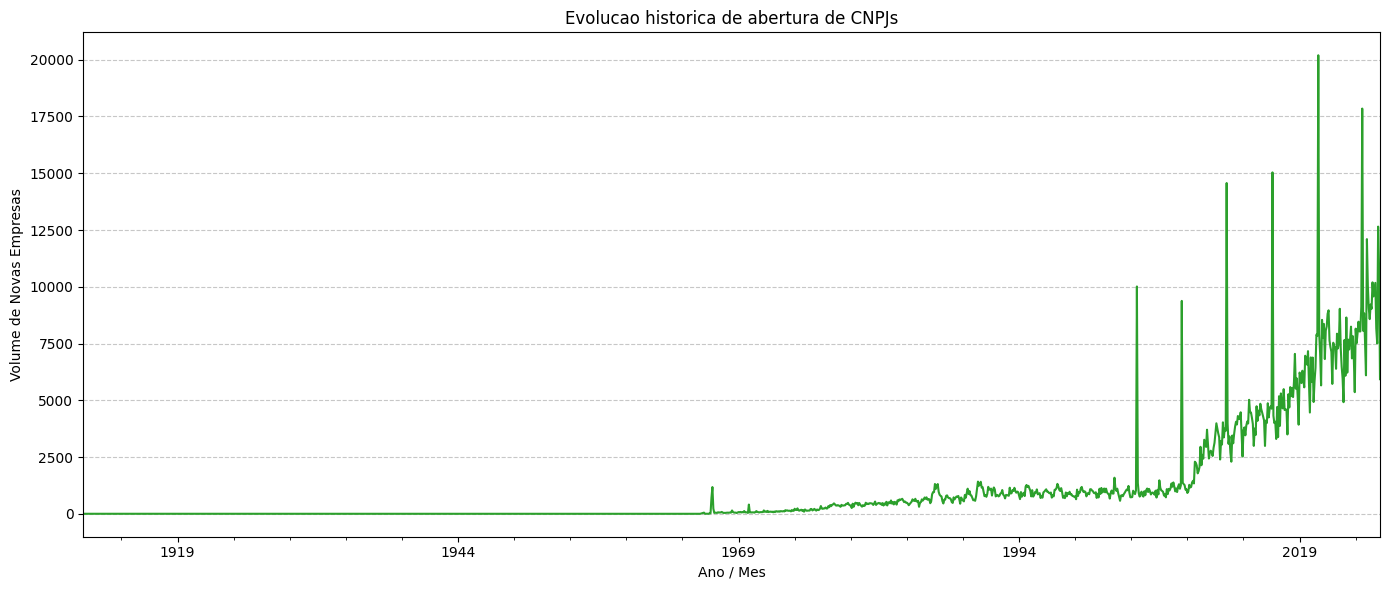

In [81]:
data['DATA'] = pd.to_datetime(data['DATA'])

data['ANO_MES'] = data['DATA'].dt.to_period('M')

aberturas_historicas = data.groupby('ANO_MES').size()

plt.figure(figsize=(14,6))
aberturas_historicas.plot(kind='line', color='#2ca02c')

plt.title('Evolucao historica de abertura de CNPJs')
plt.xlabel('Ano / Mes')
plt.ylabel('Volume de Novas Empresas')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()

plt.show()

<p>Com esta visualização podemos ver que pouco tempo antes do ano de 2019 para frente foram abertos vários CNPJs, o que torna o nosso projeto funcional devido à alta demanda e expansão do mercado de novos empreendedores.</p>
<br>

## Visualização do Top 10 maior volume de atividades na modalidade MEI

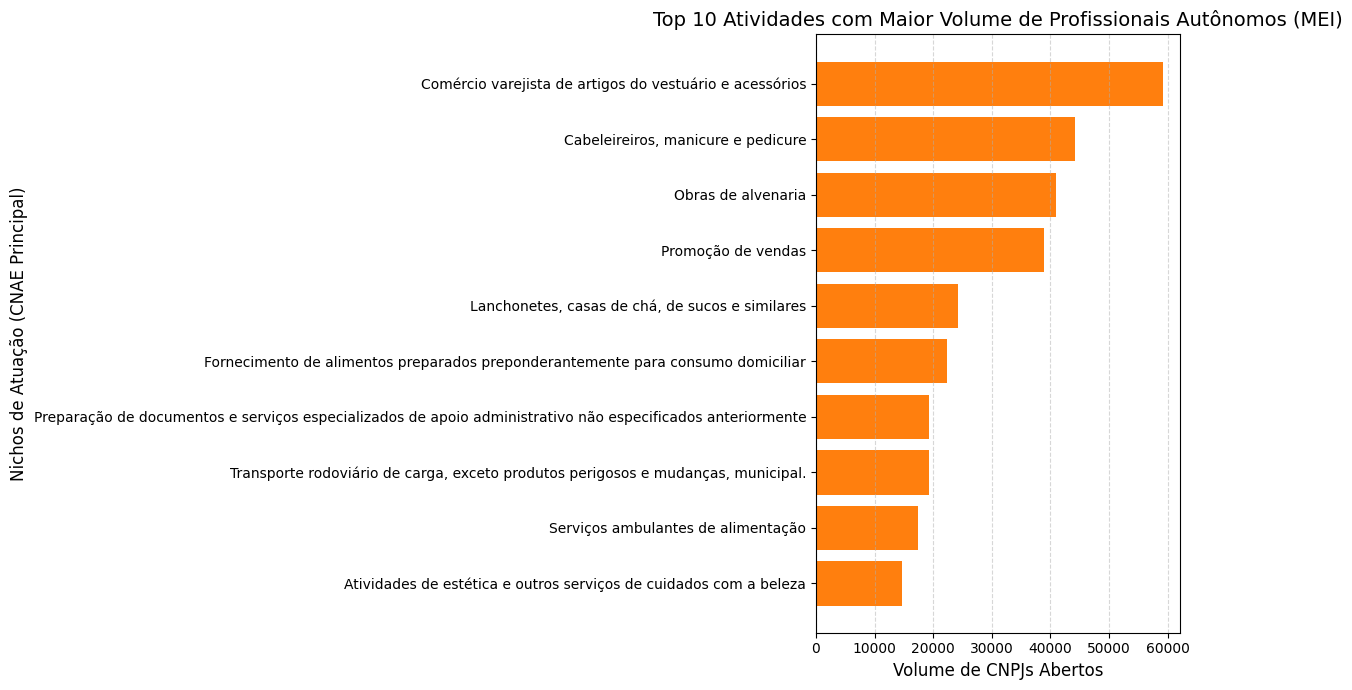

In [82]:
df_cnae = pd.read_parquet("project/data/dim_atividades_economicas.parquet")

df_cnae.columns = ['ID_ATIVIDADE', 'CODIGO_CNAE', 'CNAE_FISCAL_PRINCIPAL']

meis_ativos = data[data['DATA_OPCAO_MEI'].notna()]

top_nichos_mei = meis_ativos['ATIVIDADE'].value_counts().head(10).reset_index()

top_nichos_mei.columns = ['ID_ATIVIDADE_FATO', 'QUANTIDADE']


top_nichos_mei_desc = top_nichos_mei.merge(
    df_cnae[['ID_ATIVIDADE', 'CNAE_FISCAL_PRINCIPAL']], 
    left_on='ID_ATIVIDADE_FATO',
    right_on='ID_ATIVIDADE',
    how='left'
)

plt.figure(figsize=(12, 7))

dados_grafico = top_nichos_mei_desc.sort_values(by='QUANTIDADE', ascending=True)

plt.barh(dados_grafico['CNAE_FISCAL_PRINCIPAL'], dados_grafico['QUANTIDADE'], color='#ff7f0e')

plt.title('Top 10 Atividades com Maior Volume de Profissionais Autônomos (MEI)', fontsize=14)
plt.xlabel('Volume de CNPJs Abertos', fontsize=12)
plt.ylabel('Nichos de Atuação (CNAE Principal)', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

<p>Essa visualização em barras nos apresenta as 10 maiores atividades de profissionais MEI. Com isso é possível validar que a maior atividade principal é Comércio varejista de artigos do vestuário e acessórios, sendo uma das atividades que o sistema propõe a auxiliar na criação da sua empresa.</p>
<br>

## Visualização das 10 cidades com maior taxa de mortalidade de CNPJs

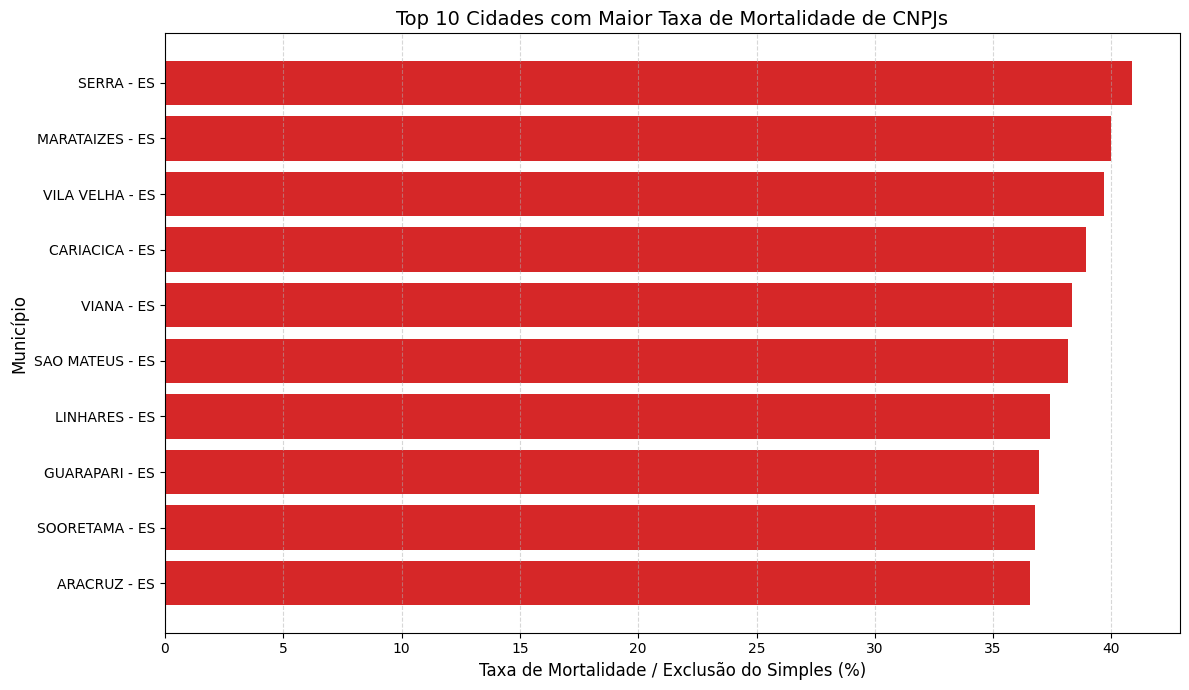

In [83]:

df_localidade = pd.read_parquet("project/data/dim_localidades.parquet")
mortalidade_id = data.groupby('LOCALIDADE')[['CNPJ', 'DATA_EXCLUSAO_SIMPLES']].count().reset_index()
mortalidade_id = mortalidade_id.rename(columns={
    'CNPJ': 'total_empresas', 
    'DATA_EXCLUSAO_SIMPLES': 'excluidas_simples'
})

mortalidade_cidade = mortalidade_id.merge(
    df_localidade[['ID_LOCALIDADE', 'MUNICIPIO', 'UF']], 
    left_on='LOCALIDADE',
    right_on='ID_LOCALIDADE',
    how='left'
)

mortalidade_agrupada = mortalidade_cidade.groupby(['MUNICIPIO', 'UF'])[['total_empresas', 'excluidas_simples']].sum().reset_index()

mortalidade_agrupada['CIDADE_UF'] = mortalidade_agrupada['MUNICIPIO'] + ' - ' + mortalidade_agrupada['UF']

mortalidade_agrupada = mortalidade_agrupada[mortalidade_agrupada['total_empresas'] > 1000].copy()

mortalidade_agrupada['taxa_mortalidade_%'] = (mortalidade_agrupada['excluidas_simples'] / mortalidade_agrupada['total_empresas']) * 100

piores_cidades = mortalidade_agrupada.sort_values('taxa_mortalidade_%', ascending=False).head(10)

plt.figure(figsize=(12, 7))

dados_grafico = piores_cidades.sort_values(by='taxa_mortalidade_%', ascending=True)

plt.barh(dados_grafico['CIDADE_UF'], dados_grafico['taxa_mortalidade_%'], color='#d62728')

plt.title('Top 10 Cidades com Maior Taxa de Mortalidade de CNPJs', fontsize=14)
plt.xlabel('Taxa de Mortalidade / Exclusão do Simples (%)', fontsize=12)
plt.ylabel('Município', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

<p>A partir da visualização do gráfico de barras é possível observar que existem cidades com maior taxa de mortalidade. É importante destacar que algumas regiões podem possuir taxa alta devido à baixa quantidade de CNPJs abertos, porém a cidade que lidera é Serra, Marataízes e Vila Velha. Portanto a principal função da aplicação é auxiliar que novos CNPJs na modalidade MEI possam crescer e fugir dessa visualização.</p>
<br>

## Cálculo da idade média do MEI x Não-MEI

In [84]:
data['idade_dias'] = (pd.Timestamp.now() - data['DATA']).dt.days

grupo_mei = data[data['DATA_OPCAO_MEI'].notna()]['idade_dias'].dropna()
grupo_nao_mei = data[data['DATA_OPCAO_MEI'].isna()]['idade_dias'].dropna()

media_mei = grupo_mei.mean() / 365
media_nao_mei = grupo_nao_mei.mean() / 365

print(f"Idade Média MEI: {media_mei:.2f} anos")
print(f"Idade Média Não-MEI: {media_nao_mei:.2f} anos")

Idade Média MEI: 6.64 anos
Idade Média Não-MEI: 20.19 anos


<p>Com  esse resultado podemos comprovar que existe sim uma disparidade quanto o tempo médio de vida das empresas que são MEI, visando isso a nossa aplicação vem com a proposta de solucionar e aumentar a longeividade da sua empresa por meio de representações de taxa de crescimento a partir da análise geográfica e análise de concorrência da sua região.</p>

<h2>Conclusão</h2>

<p>Com os testes e visualizações aplicados podemos confirmar que a aplicação pode apresentar um enorme ganho para os clientes que possuem porte MEI e estão buscando crescimento ou sobrevivência, devido os resultados encontrados no EDA concluímos que o porte que possue mais abertura de novos CNPJs e mais encerramento é o MEI. Portanto, o nosso foco é trazer ganho para esse público, permitindo um aumento do seu tempo de sobrevivência e evolução.</p>